In [2]:
import numpy as np
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet, LinearRegression
import xgboost as xgb
import matplotlib.pyplot as plt

import openbb as obb
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import norm, skewnorm, t

In [3]:
output = obb.obb.equity.price.historical("AAPL", start_date="2014-01-01",provider="yfinance")
df = output.to_dataframe()


1 Failed download:
['AAPL']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


EmptyDataError: 
[Empty] -> No results found. Try adjusting the query parameters.

In [92]:
df.head()

,open,high,low,close,volume,split_ratio,dividend
date,,,,,,,
2014-01-02,19.845715,19.893929,19.715000,19.754642,234684800,0.0,0.0
2014-01-03,19.745001,19.775000,19.301071,19.320715,392467600,0.0,0.0
2014-01-06,19.194643,19.528570,19.057142,19.426071,412610800,0.0,0.0
2014-01-07,19.440001,19.498571,19.211430,19.287144,317209200,0.0,0.0
2014-01-08,19.243214,19.484285,19.238930,19.409286,258529600,0.0,0.0


<Axes: >

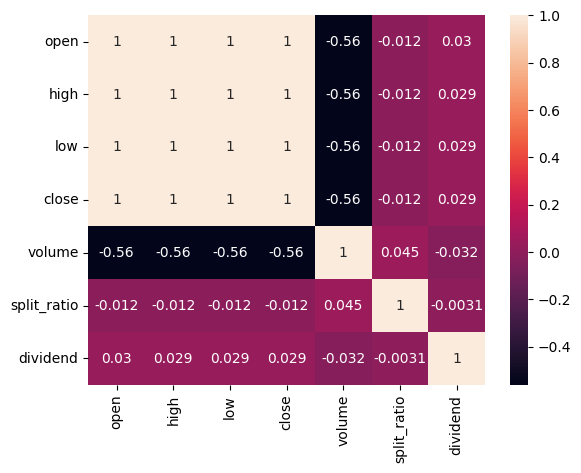

In [93]:
sns.heatmap(df.corr(), annot=True)

In [124]:
df["return"] = df["close"]-df["open"]
df["log_return"] = np.log(df["close"] / df["open"])
df["log_return_rol"] = df["log_return"].rolling(30).sum()
df["log_return_std"] = df["log_return"].rolling(30).std()
# Convert back to percent return:
df["log_return_rol_pct"] = (np.exp(df["log_return_rol"]) - 1) * 100


In [97]:
df.head(
)

,open,high,low,close,volume,split_ratio,dividend,log_return,log_return_rol,log_return_rol_pct,return,return_pct
date,,,,,,,,,,,,
2014-01-02,19.845715,19.893929,19.715000,19.754642,234684800,0.0,0.0,-0.004600,NaN,NaN,-0.091072,NaN
2014-01-03,19.745001,19.775000,19.301071,19.320715,392467600,0.0,0.0,-0.021723,NaN,NaN,-0.424286,3.658792
2014-01-06,19.194643,19.528570,19.057142,19.426071,412610800,0.0,0.0,0.011985,NaN,NaN,0.231428,-1.545453
2014-01-07,19.440001,19.498571,19.211430,19.287144,317209200,0.0,0.0,-0.007894,NaN,NaN,-0.152857,-1.660494
2014-01-08,19.243214,19.484285,19.238930,19.409286,258529600,0.0,0.0,0.008593,NaN,NaN,0.166073,-2.086460


In [126]:
df = df.dropna()
df.head(
)

,open,high,low,close,volume,split_ratio,dividend,log_return,log_return_rol,log_return_rol_pct,return,return_pct,std_rol,log_return_std
date,,,,,,,,,,,,,,
2014-03-27,19.286428,19.339287,19.111429,19.195000,222031600,0.0,0.0,-0.004752,-0.020544,-2.033453,-0.091429,-0.620178,0.008836,0.008836
2014-03-28,19.225714,19.247856,19.080357,19.173571,200564000,0.0,0.0,-0.002716,-0.041368,-4.052441,-0.052143,-0.429686,0.008096,0.008096
2014-03-31,19.258215,19.314644,19.140356,19.169287,168669200,0.0,0.0,-0.004628,-0.048795,-4.762348,-0.088928,0.705465,0.008077,0.008077
2014-04-01,19.205713,19.352501,19.170357,19.344643,200760000,0.0,0.0,0.007208,-0.041569,-4.071668,0.138929,-2.562264,0.008233,0.008233
2014-04-02,19.370714,19.410000,19.295000,19.376785,180420800,0.0,0.0,0.000313,-0.027615,-2.723756,0.006071,-0.956301,0.007905,0.007905


<Axes: xlabel='log_return', ylabel='Count'>

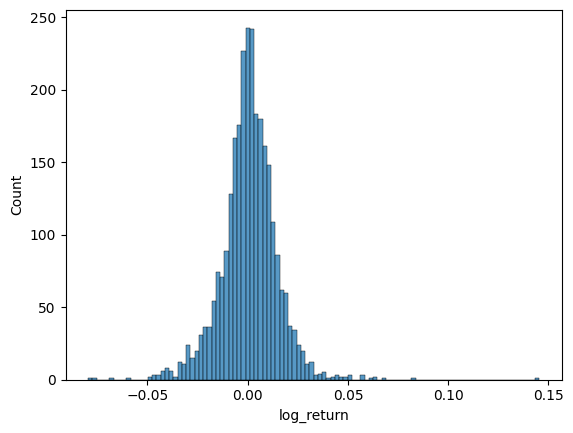

In [99]:
sns.histplot(df["log_return"][np.abs(df["log_return"])<10.0])


In [71]:
from scipy import stats

In [100]:
p_value = stats.shapiro(df["log_return"][df["log_return"]<20.0])

In [101]:
p_value[1]

np.float64(2.2989285300151455e-29)

In [102]:
skewnorm.fit(df["log_return"][np.abs(df["log_return"])<10.0])

(np.float64(0.802449958023965),
 np.float64(-0.007327309271545566),
 np.float64(0.01619594592425822))

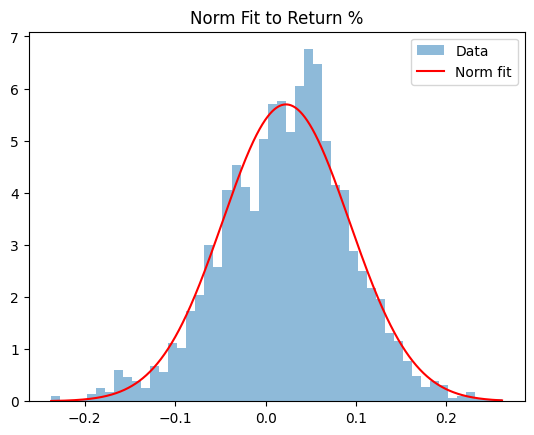

In [117]:
filtered = df["log_return_rol"][np.abs(df["log_return_rol"]) < 10.0]
params_norm = norm.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = norm.pdf(x, *params_norm)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Norm fit")
plt.legend()
plt.title("Norm Fit to Return %")
plt.show()

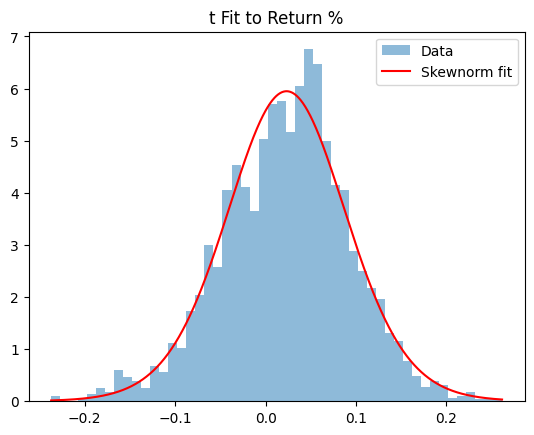

In [118]:
filtered = df["log_return_rol"][np.abs(df["log_return_rol"]) < 10.0]
params_t = t.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = t.pdf(x, *params_t)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Skewnorm fit")
plt.legend()
plt.title("t Fit to Return %")
plt.show()

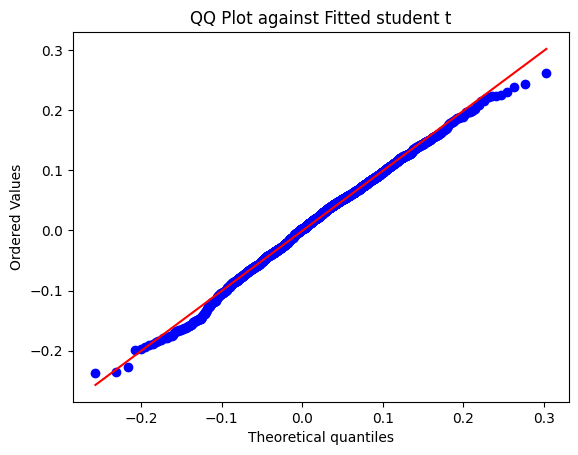

In [111]:
stats.probplot(filtered, dist=t(*params_t), plot=plt)
plt.title("QQ Plot against Fitted student t")
plt.show()


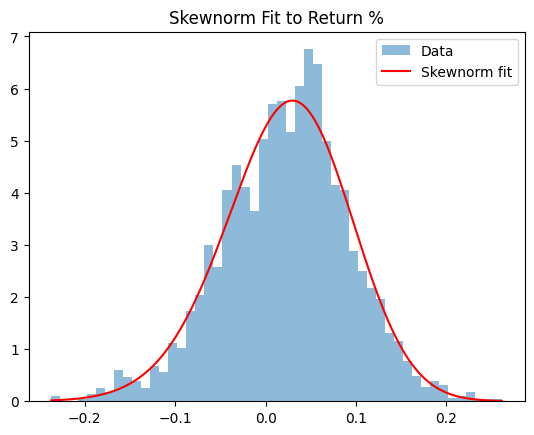

In [112]:
filtered = df["log_return_rol"][np.abs(df["log_return_rol"]) < 10.0]
params_skew = skewnorm.fit(filtered)

x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf = skewnorm.pdf(x, *params_skew)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf, 'r-', label="Skewnorm fit")
plt.legend()
plt.title("Skewnorm Fit to Return %")
plt.show()

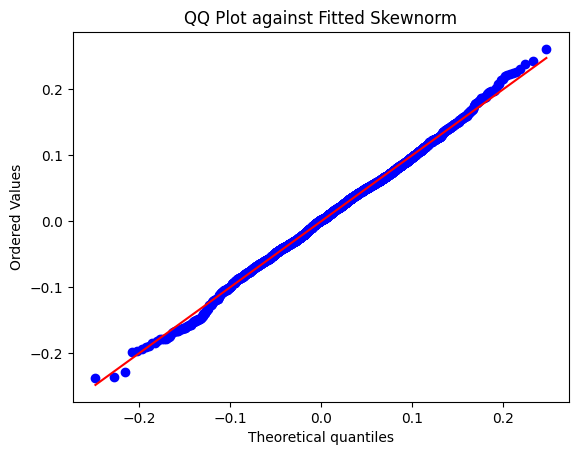

In [113]:
stats.probplot(filtered, dist=skewnorm(*params_skew), plot=plt)
plt.title("QQ Plot against Fitted Skewnorm")
plt.show()

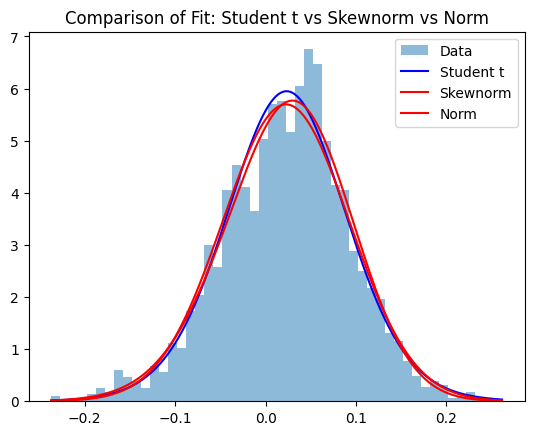

In [119]:
x = np.linspace(filtered.min(), filtered.max(), 1000)
pdf_t = t.pdf(x, *params_t)
pdf_skew = skewnorm.pdf(x, *params_skew)
pdf_norm = norm.pdf(x, *params_norm)

plt.hist(filtered, bins=50, density=True, alpha=0.5, label="Data")
plt.plot(x, pdf_t, 'b-', label="Student t")
plt.plot(x, pdf_skew, 'r-', label="Skewnorm")
plt.plot(x, pdf_norm, 'r-', label="Norm")
plt.legend()
plt.title("Comparison of Fit: Student t vs Skewnorm vs Norm")
plt.show()


<Axes: xlabel='log_return_rol', ylabel='Count'>

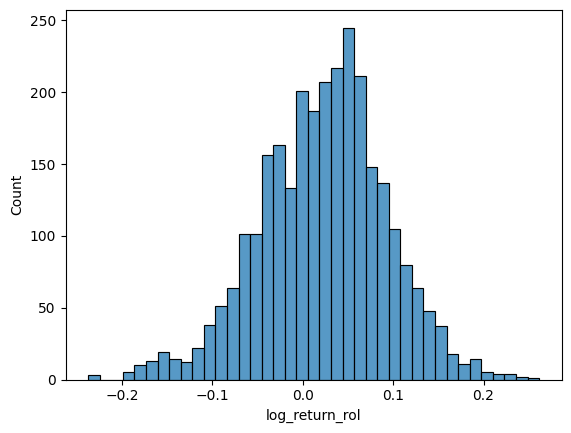

In [109]:
sns.histplot(df["log_return_rol"])

In [127]:
df.head()

,open,high,low,close,volume,split_ratio,dividend,log_return,log_return_rol,log_return_rol_pct,return,return_pct,std_rol,log_return_std
date,,,,,,,,,,,,,,
2014-03-27,19.286428,19.339287,19.111429,19.195000,222031600,0.0,0.0,-0.004752,-0.020544,-2.033453,-0.091429,-0.620178,0.008836,0.008836
2014-03-28,19.225714,19.247856,19.080357,19.173571,200564000,0.0,0.0,-0.002716,-0.041368,-4.052441,-0.052143,-0.429686,0.008096,0.008096
2014-03-31,19.258215,19.314644,19.140356,19.169287,168669200,0.0,0.0,-0.004628,-0.048795,-4.762348,-0.088928,0.705465,0.008077,0.008077
2014-04-01,19.205713,19.352501,19.170357,19.344643,200760000,0.0,0.0,0.007208,-0.041569,-4.071668,0.138929,-2.562264,0.008233,0.008233
2014-04-02,19.370714,19.410000,19.295000,19.376785,180420800,0.0,0.0,0.000313,-0.027615,-2.723756,0.006071,-0.956301,0.007905,0.007905


<Axes: xlabel='log_return_std', ylabel='Count'>

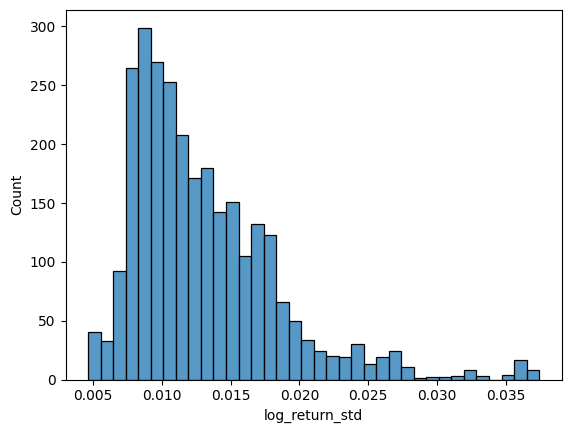

In [128]:
sns.histplot(df["log_return_std"])

In [139]:
VaR = norm.ppf(0.05, *params_norm)
VaR_skew = skewnorm.ppf(0.05, *params_skew)
Var_t = t.ppf(0.05, *params_t)

In [140]:
VaR, VaR_skew, Var_t

(np.float64(-0.09265882111337519),
 np.float64(-0.09659213298616162),
 np.float64(-0.0913874785916638))

In [1]:
def calculate_expected_var_norm(conf_level,mu, std ):

    ES = mu - std * norm.pdf(norm.ppf(1-conf_level)) / (1-conf_level)
    return ES

def calculate_expected_var_t(conf_level, df, loc, scale):

    t_alpha = t.ppf(1-conf_level, df)
    pdf = t.pdf(t_alpha, df)
    ES = loc - scale * ( (df + t_alpha**2) / (df - 1) ) * pdf / (1-conf_level)
    return ES

def calculated_expected_var_skew(conf_level, a, loc, scale):

    VaR_skew = skewnorm.ppf(1-conf_level, a, loc, scale)
    x = np.linspace(-10, VaR_skew, 1000)
    pdf_vals = skewnorm.pdf(x, a, loc, scale)
    ES = np.trapezoid(x * pdf_vals, x) / skewnorm.cdf(VaR_skew, a, loc, scale)
    return ES
